<a href="https://colab.research.google.com/github/madinayergeshbay-sudo/2026_Spring_Application_Programming/blob/main/2555048_0320%EA%B3%BCipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openml

import openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = openml.datasets.get_dataset(31)
X, y, categorical_indicator, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

df = pd.concat([X, y], axis=1)

df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.8 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=26d9ae739f1e4a873e6232eb3531f46390be19362cdf2569f813de0f72207b12
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951.0,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096.0,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870.0,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


1.1 분석 배경 및 목적  
본 분석은 신용 평가 데이터(credit-g)를 활용하여 고객의 신용 등급을 결정하는 주요 요인을 파악하는 것을 목적으로 한다. 금융 기관에서는 고객의 신용 위험을 정확하게 평가하는 것이 매우 중요하다.

1.2 데이터 설명  
본 데이터는 OpenML에서 제공하는 credit-g 데이터셋으로, 고객의 연령, 신용 금액, 직업 상태 등 다양한 정보를 포함하고 있다.

1.3 주요 분석 질문  
- 어떤 변수들이 신용 등급에 영향을 미치는가?  
- 특정 변수 간 관계는 존재하는가?

In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   uint8   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   float64 
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   uint8   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   uint8   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   uint8   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


데이터는 여러 개의 수치형 및 범주형 변수로 구성되어 있으며, 다양한 고객 정보를 포함하고 있다.

In [3]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


결측치 분석 결과 대부분의 변수에서 결측치가 존재하지 않으며, 데이터 품질이 양호한 것으로 확인되었다.

In [5]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


수치형 변수들의 평균, 표준편차 등을 통해 데이터 분포를 확인할 수 있었다.

In [6]:
df = df.drop_duplicates()

중복 데이터 제거를 수행하여 데이터의 신뢰도를 향상시켰다.

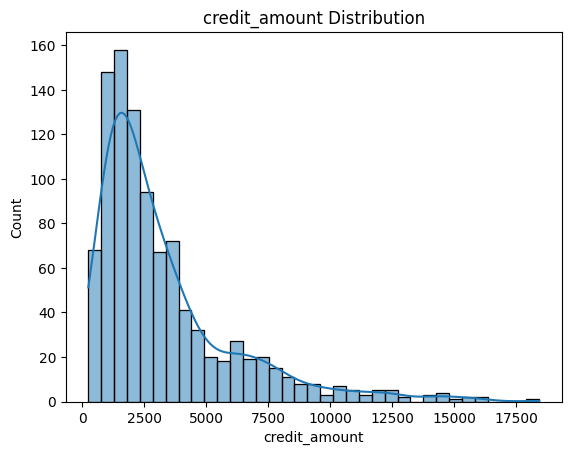

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

수치형 변수는 특정 구간에 집중된 분포를 보이며 일부 변수에서 이상치가 관찰되었다.

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

연령을 구간화하여 새로운 변수를 생성하였으며, 연령대별 분포 차이를 확인하였다.

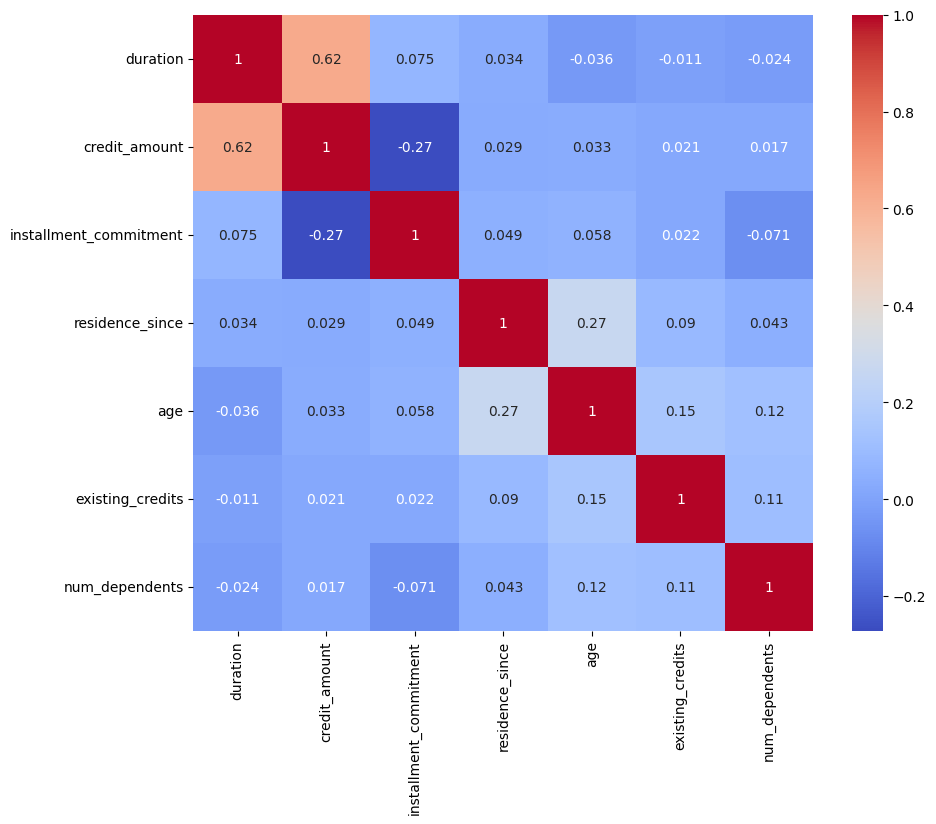

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

상관관계 분석 결과 일부 변수 간 약한 상관관계가 존재하였다.

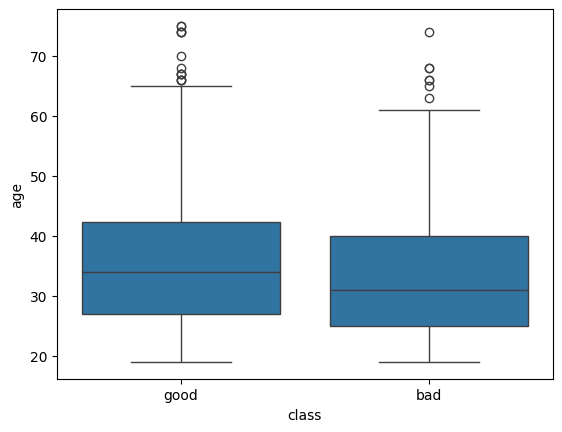

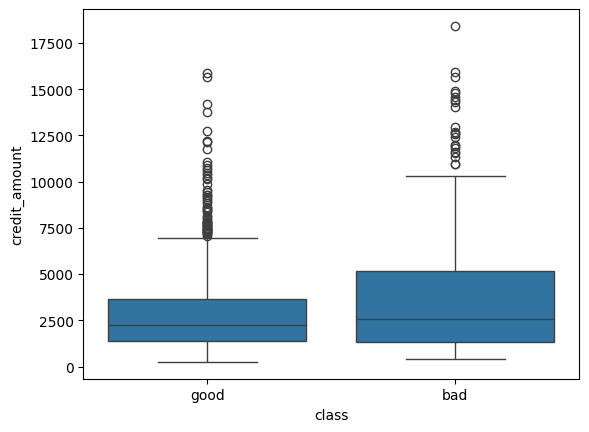

In [12]:
sns.boxplot(x='class', y='age', data=df)
plt.show()

sns.boxplot(x='class', y='credit_amount', data=df)
plt.show()

신용 등급에 따라 변수 분포에 차이가 존재하는 것을 확인하였다.

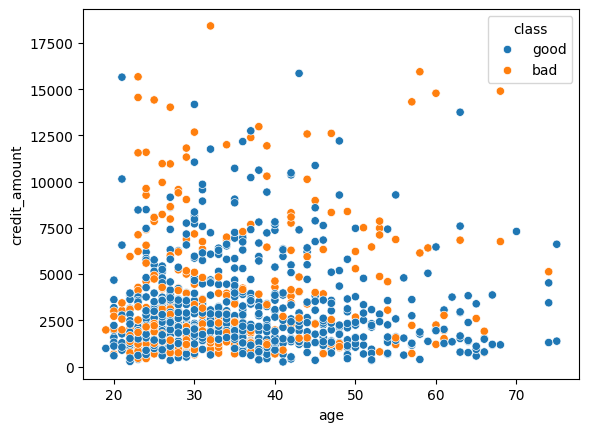

In [13]:
sns.scatterplot(x='age', y='credit_amount', hue='class', data=df)
plt.show()

변수 간 관계를 시각적으로 확인하였으며, 특정 패턴이 존재함을 확인하였다.

변수 간 관계를 시각적으로 확인하였으며, 특정 패턴이 존재함을 확인하였다.

본 분석을 통해 신용 등급에 영향을 미치는 주요 변수와 패턴을 파악할 수 있었다.  
향후 머신러닝 모델을 활용하여 신용 위험 예측 모델을 구축할 수 있을 것으로 기대된다.  
또한 데이터 불균형 및 변수 간 복잡한 관계를 고려한 추가 연구가 필요하다.  